In [105]:
!pip install --user mysql-connector-python --break-system-packages

In [106]:
import mysql.connector

In [107]:
#input the credentials
connection = mysql.connector.connect(
    host="127.0.0.1",  # Hostname
    user="",   # Username
    password="",  # Password
    database=""  # Database name
)

cursor = connection.cursor()

# Run only once

In [4]:
# create patient table

cursor.execute("""
CREATE TABLE patient_data (
    pid BIGINT PRIMARY KEY,
    DOB DATE,
    sex VARCHAR(10),
    city VARCHAR(100),
    state VARCHAR(100)
)
""")

In [5]:
# create facility table

cursor.execute("""
CREATE TABLE facility (
    id INT PRIMARY KEY,
    name VARCHAR(255),
    city VARCHAR(100),
    state VARCHAR(100)
)
""")

In [6]:
# create form_encounter table

cursor.execute("""
CREATE TABLE form_encounter (
    id BIGINT PRIMARY KEY,
    pid BIGINT,
    facility_id INT,
    date DATE,
    reason_for_visit VARCHAR(255),
    CONSTRAINT fk_encounter_patient
        FOREIGN KEY (pid)
        REFERENCES patient_data(pid)
        ON DELETE CASCADE ON UPDATE CASCADE,
    CONSTRAINT fk_encounter_facility
        FOREIGN KEY (facility_id)
        REFERENCES facility(id)
        ON DELETE SET NULL ON UPDATE CASCADE
)
""") 

In [7]:
# create immunizations table

cursor.execute("""
CREATE TABLE immunizations (
    id BIGINT PRIMARY KEY,
    pid BIGINT,
    administered_date DATE,
    cdc_vaccine_code VARCHAR(50),
    CONSTRAINT fk_immun_patient
        FOREIGN KEY (pid)
        REFERENCES patient_data(pid)
        ON DELETE CASCADE ON UPDATE CASCADE
)
""") 

In [8]:
# create prescriptions table

cursor.execute("""
CREATE TABLE prescriptions (
    id BIGINT PRIMARY KEY,
    encounter_id BIGINT,
    date_prescribed DATETIME,
    drug_name VARCHAR(255),
    CONSTRAINT fk_presc_encounter
        FOREIGN KEY (encounter_id)
        REFERENCES form_encounter(id)
        ON DELETE CASCADE
        ON UPDATE CASCADE
)
""")

In [4]:
# Insert data 

#import csv module
import csv

In [5]:
print("Clearing existing data from patient_data table...")
cursor.execute("DELETE FROM patient_data")
connection.commit()

# Populate data to patient_data table 
with open('patient_data.csv', 'r', encoding='latin-1') as f:
    csv_reader = csv.reader(f)
    next(csv_reader)  # Skip header row
    
    inserted_count = 0
    
    for row in csv_reader:
        pid = row[0]      # id column (index 0)
        dob = row[8]      # DOB column (index 8)
        sex = row[25]     # sex column (index 25 - LAST COLUMN)
        city = row[11]    # city column (index 11)
        state = row[12]   # state column (index 12)
        
        cursor.execute(
            "INSERT INTO patient_data (pid, DOB, sex, city, state) VALUES (%s, %s, %s, %s, %s)",
            (pid, dob, sex, city, state)
        )
        inserted_count += 1

# Commit changes
connection.commit()

print(f"Successfully inserted {inserted_count} records into patient_data table")

Clearing existing data from patient_data table...
Successfully inserted 100 records into patient_data table


In [6]:
print("\n2. Populating facility table...")
# cursor.execute("DELETE FROM facility")  

with open('facility.csv', 'r', encoding='iso-8859-1') as f:
    csv_reader = csv.reader(f)
    next(csv_reader)  # Skip header
    
    count = 0
    for row in csv_reader:
        facility_id = row[0]    # id (index 0)
        name = row[2]           # name (index 2)
        city = row[6]           # city (index 6)
        state = row[7]          # state (index 7)
        
        cursor.execute(
            "INSERT INTO facility (id, name, city, state) VALUES (%s, %s, %s, %s)",
            (facility_id, name, city, state)
        )
        count += 1

connection.commit()
print(f"   ✓ Inserted {count} records into facility")


2. Populating facility table...
   ✓ Inserted 7 records into facility


In [ ]:
print("\n3. Populating form_encounter table...")
# cursor.execute("DELETE FROM form_encounter")  Uncomment if tables have existing data

with open('form_encounter.csv', 'r', encoding='iso-8859-1') as f:
    csv_reader = csv.reader(f)
    next(csv_reader)  # Skip header
    
    count = 0
    for row in csv_reader:
        encounter_id = row[0]      # id (index 0)
        date = row[2]              # date (index 2)
        reason = row[3]            # reason (index 3)
        facility_id = row[5]       # facility_id (index 5)
        pid = row[6]               # pid (index 6)
        
        # Handle date format - MySQL expects YYYY-MM-DD
        # If date is empty or NULL, use None
        if not date or date.upper() == 'NULL':
            date = None
        
        cursor.execute(
            "INSERT INTO form_encounter (id, pid, facility_id, date, reason_for_visit) VALUES (%s, %s, %s, %s, %s)",
            (encounter_id, pid, facility_id, date, reason)
        )
        count += 1

connection.commit()
print(f"   ✓ Inserted {count} records into form_encounter") 

In [7]:
print("\n3. Populating form_encounter table...")
# cursor.execute("DELETE FROM form_encounter")  # Uncomment if tables have existing data

with open('form_encounter.csv', 'r', encoding='iso-8859-1') as f:
    csv_reader = csv.reader(f)
    next(csv_reader)  # Skip header
    
    count = 0
    for row in csv_reader:
        encounter_id = row[0]      # id (index 0)
        date = row[2]              # date (index 2)
        reason = row[3]            # reason (index 3)
        facility_id = row[5]       # facility_id (index 5)
        pid = row[6]               # pid (index 6)
        
        # Handle date format - MySQL expects YYYY-MM-DD
        # If date is empty or NULL, use None
        if not date or date.upper() == 'NULL':
            date = None
        
        cursor.execute(
            "INSERT INTO form_encounter (id, pid, facility_id, date, reason_for_visit) VALUES (%s, %s, %s, %s, %s)",
            (encounter_id, pid, facility_id, date, reason)
        )
        count += 1

connection.commit()
print(f"   ✓ Inserted {count} records into form_encounter")


3. Populating form_encounter table...
   ✓ Inserted 4323 records into form_encounter


In [8]:
print("\n4. Populating immunizations table...")
# cursor.execute("DELETE FROM immunizations")  # Uncomment if tables have existing data

with open('immunizations.csv', 'r', encoding='iso-8859-1') as f:
    csv_reader = csv.reader(f)
    next(csv_reader)  # Skip header
    
    count = 0
    for row in csv_reader:
        immun_id = row[0]           # id (index 0)
        pid = row[2]                # patient_id (index 2)
        admin_date = row[3]         # administered_date (index 3)
        cvx_code = row[5]           # cvx_code (index 5)
        
        # Handle date format
        if not admin_date or admin_date.upper() == 'NULL':
            admin_date = None
        
        cursor.execute(
            "INSERT INTO immunizations (id, pid, administered_date, cdc_vaccine_code) VALUES (%s, %s, %s, %s)",
            (immun_id, pid, admin_date, cvx_code)
        )
        count += 1

connection.commit()
print(f"   ✓ Inserted {count} records into immunizations")


4. Populating immunizations table...
   ✓ Inserted 1452 records into immunizations


In [10]:
print("\n5. Populating prescriptions table...")
# cursor.execute("DELETE FROM prescriptions")  # Uncomment if tables have existing data

with open('prescriptions.csv', 'r', encoding='iso-8859-1') as f:
    csv_reader = csv.reader(f)
    next(csv_reader)  # Skip header
    
    count = 0
    for row in csv_reader:
        presc_id = row[0]           # id (index 0)
        encounter_id = row[8]       # encounter (index 8)
        date_added = row[5]         # date_added (index 5)
        drug = row[10]              # drug (index 10)
        
        # Handle NULL encounter_id - CONVERT STRING "NULL" to actual None
        if not encounter_id or encounter_id.upper() == 'NULL':
            encounter_id = None
        
        # Handle date format - this is DATETIME in your table
        if not date_added or date_added.upper() == 'NULL':
            date_added = None
        
        cursor.execute(
            "INSERT INTO prescriptions (id, encounter_id, date_prescribed, drug_name) VALUES (%s, %s, %s, %s)",
            (presc_id, encounter_id, date_added, drug)
        )
        count += 1

connection.commit()
print(f"   ✓ Inserted {count} records into prescriptions")


5. Populating prescriptions table...
   ✓ Inserted 522 records into prescriptions


In [1]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully!")
print("=" * 70)
print("GEOGRAPHIC VARIATION IN CARE DELIVERY ANALYSIS")
print("=" * 70)

✓ Libraries imported successfully!
GEOGRAPHIC VARIATION IN CARE DELIVERY ANALYSIS


In [9]:
# CELL 2: Database Connection (use your existing connection)
# ============================================================
# You already have this from your notebook, so you can skip this cell
# or uncomment if you need a fresh connection

# connection = mysql.connector.connect(
#     host="127.0.0.1",
#     user="mkedare",
#     password="theodore journalistic wotan",
#     database="mkedare_db"
# )
# cursor = connection.cursor()

print("✓ Using existing database connection from your notebook")

✓ Using existing database connection from your notebook



Immunization Analysis by City (CORRECTED)

Top 20 Cities by Total Immunizations:
               city  total_patients  immunized_patients  total_immunizations  \
0            Boston               6                   6                   84   
1         Haverhill               4                   4                   82   
2            Revere               2                   2                   56   
3         Worcester               4                   4                   55   
4           Holyoke               3                   3                   46   
5   East Longmeadow               2                   2                   45   
6         Fairhaven               1                   1                   36   
7        Cordaville               1                   1                   36   
8          Weymouth               1                   1                   36   
9        Swampscott               2                   2                   35   
10           Dracut               1   

/tmp/ipykernel_1647328/3589745605.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_immun_city = pd.read_sql(query_immun_city, connection)


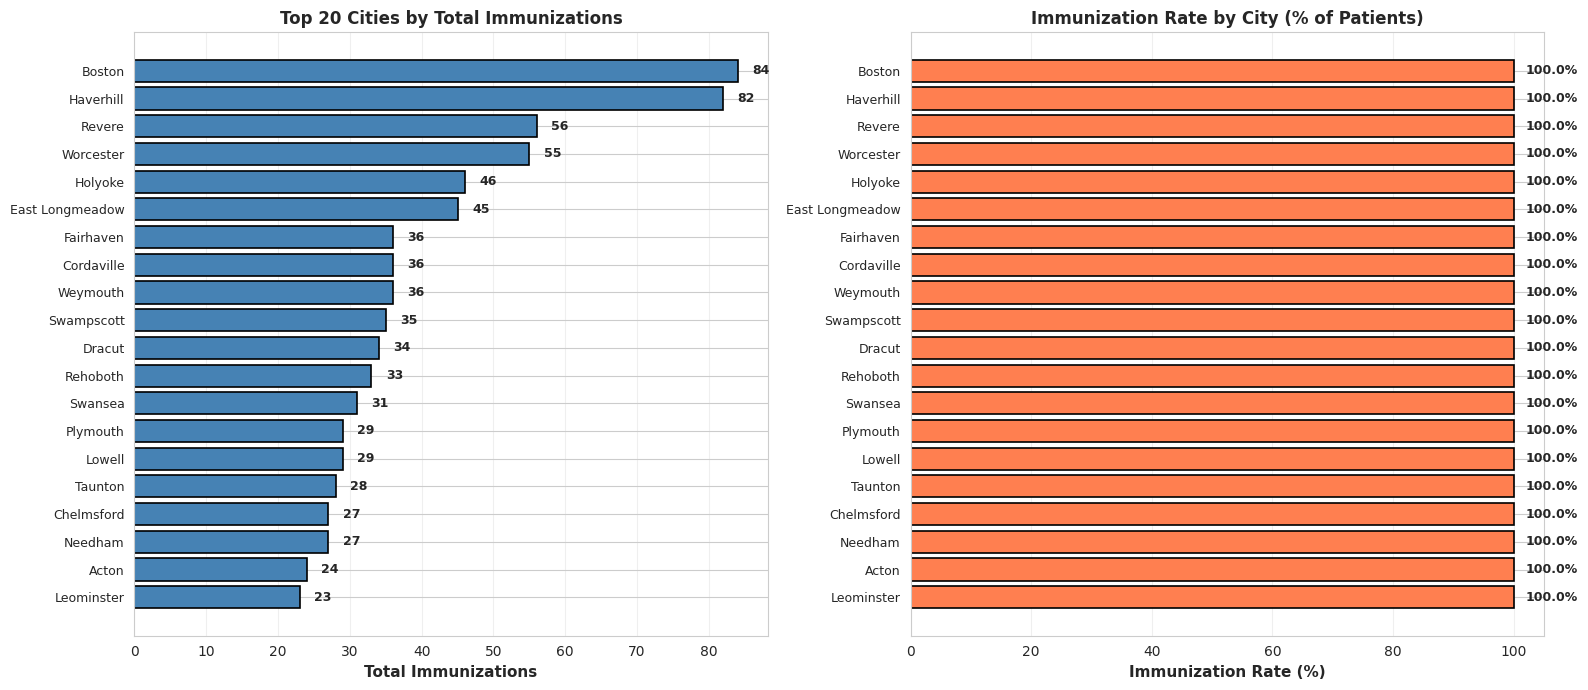


✓ Total cities with immunizations: 20
✓ Top city: Boston (84 immunizations)


In [136]:
Immunization Analysis by City
print("\n" + "="*70)
print("Immunization Analysis by City (CORRECTED)")
print("="*70)

query_immun_city = """
SELECT 
    p.city,
    COUNT(DISTINCT p.pid) as total_patients,
    COUNT(DISTINCT i.pid) as immunized_patients,
    COUNT(i.id) as total_immunizations,
    ROUND(COUNT(DISTINCT i.pid) * 100.0 / COUNT(DISTINCT p.pid), 2) as immunization_rate_pct,
    ROUND(COUNT(i.id) * 1.0 / NULLIF(COUNT(DISTINCT i.pid), 0), 2) as avg_immunizations_per_immunized_patient
FROM patient_data p
LEFT JOIN immunizations i ON p.pid = i.pid
GROUP BY p.city
HAVING total_immunizations > 0
ORDER BY total_immunizations DESC
LIMIT 20
"""

df_immun_city = pd.read_sql(query_immun_city, connection)
print("\nTop 20 Cities by Total Immunizations:")
print(df_immun_city)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Total immunizations by city
bars1 = axes[0].barh(range(len(df_immun_city)), df_immun_city['total_immunizations'],
                      color='steelblue', edgecolor='black', linewidth=1.2)
for i, (bar, count) in enumerate(zip(bars1, df_immun_city['total_immunizations'])):
    axes[0].text(count + 2, bar.get_y() + bar.get_height()/2,
                 f'{int(count)}',
                 va='center', fontsize=9, fontweight='bold')

axes[0].set_yticks(range(len(df_immun_city)))
axes[0].set_yticklabels(df_immun_city['city'], fontsize=9)
axes[0].set_xlabel('Total Immunizations', fontsize=11, fontweight='bold')
axes[0].set_title('Top 20 Cities by Total Immunizations', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Immunization rate by city
bars2 = axes[1].barh(range(len(df_immun_city)), df_immun_city['immunization_rate_pct'],
                      color='coral', edgecolor='black', linewidth=1.2)
for i, (bar, rate) in enumerate(zip(bars2, df_immun_city['immunization_rate_pct'])):
    axes[1].text(rate + 2, bar.get_y() + bar.get_height()/2,
                 f'{rate:.1f}%',
                 va='center', fontsize=9, fontweight='bold')

axes[1].set_yticks(range(len(df_immun_city)))
axes[1].set_yticklabels(df_immun_city['city'], fontsize=9)
axes[1].set_xlabel('Immunization Rate (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Immunization Rate by City (% of Patients)', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\n✓ Total cities with immunizations: {len(df_immun_city)}")
print(f"✓ Top city: {df_immun_city.iloc[0]['city']} ({int(df_immun_city.iloc[0]['total_immunizations'])} immunizations)")


Q2: Do patients from different regions show differences in encounter frequency or follow-up rates?

Encounter frequency by state:
           state  total_patients  total_encounters  avg_encounters_per_patient
0  Massachusetts             100              4323                       43.23


/tmp/ipykernel_1647328/2344294858.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q2a = pd.read_sql(query_q2a, connection)
/tmp/ipykernel_1647328/2344294858.py:56: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q2b = pd.read_sql(query_q2b, connection)



Follow-up rates by state:
           state  initial_encounters  followup_encounters  followup_rate  \
0  Massachusetts                4323                 1339          30.97   

   avg_days_to_followup  
0                  15.5  


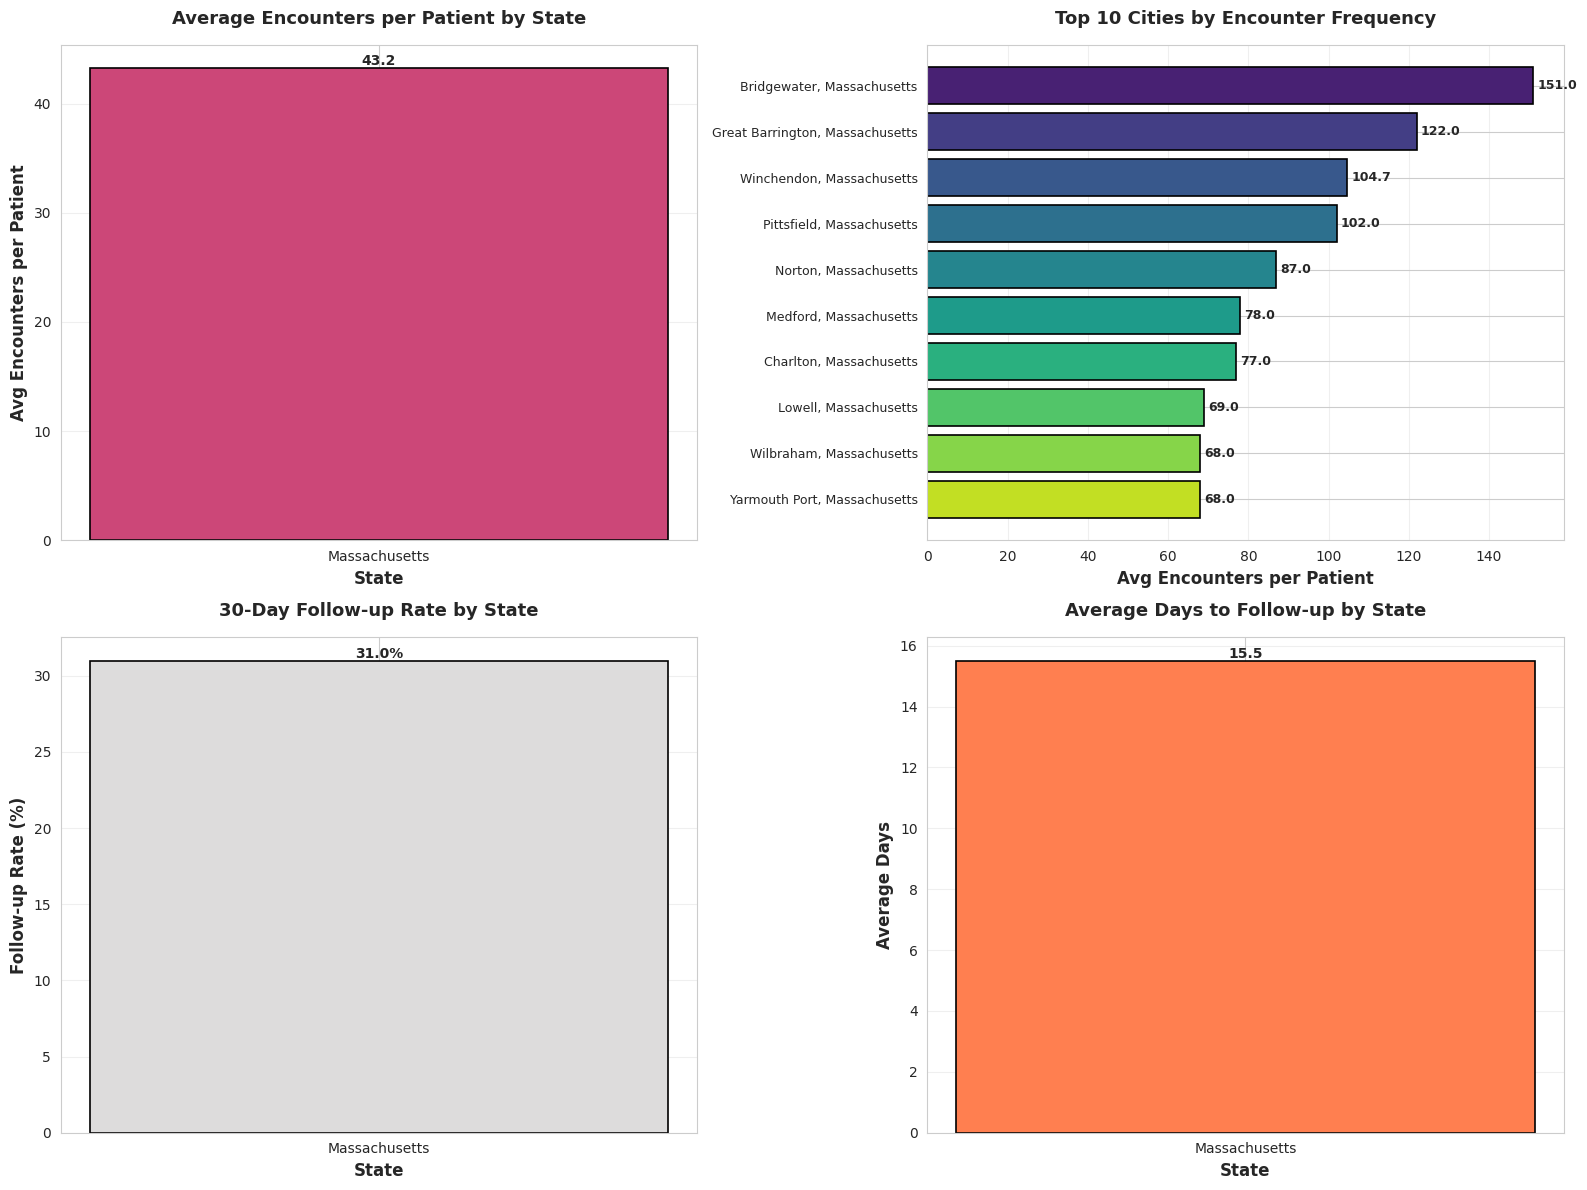


 State with highest encounter frequency: Massachusetts (43.2 encounters/patient)
 State with highest follow-up rate: Massachusetts (31.0%)


In [55]:
# QUESTION 2: Encounter Frequency and Follow-up Rates by Region
# ============================================================
print("\n" + "="*70)
print("Q2: Do patients from different regions show differences in encounter frequency or follow-up rates?")
print("="*70)

# Part A: Encounter Frequency
query_q2a = """
SELECT 
    p.state,
    p.city,
    COUNT(DISTINCT p.pid) as total_patients,
    COUNT(e.id) as total_encounters,
    ROUND(COUNT(e.id) * 1.0 / COUNT(DISTINCT p.pid), 2) as avg_encounters_per_patient,
    ROUND(COUNT(DISTINCT e.pid) * 100.0 / COUNT(DISTINCT p.pid), 2) as patient_encounter_rate
FROM patient_data p
LEFT JOIN form_encounter e ON p.pid = e.pid
GROUP BY p.state, p.city
ORDER BY avg_encounters_per_patient DESC
"""

df_q2a = pd.read_sql(query_q2a, connection)

# State-level summary for encounter frequency
df_q2a_state = df_q2a.groupby('state').agg({
    'total_patients': 'sum',
    'total_encounters': 'sum'
}).reset_index()
df_q2a_state['avg_encounters_per_patient'] = (
    df_q2a_state['total_encounters'] / df_q2a_state['total_patients']
).round(2)
df_q2a_state = df_q2a_state.sort_values('avg_encounters_per_patient', ascending=False)

print("\nEncounter frequency by state:")
print(df_q2a_state)

# Part B: Follow-up Rates
query_q2b = """
SELECT 
    p.state,
    COUNT(DISTINCT e1.id) as initial_encounters,
    COUNT(DISTINCT e2.id) as followup_encounters,
    ROUND(COUNT(DISTINCT e2.id) * 100.0 / NULLIF(COUNT(DISTINCT e1.id), 0), 2) as followup_rate,
    ROUND(AVG(DATEDIFF(e2.date, e1.date)), 1) as avg_days_to_followup
FROM patient_data p
JOIN form_encounter e1 ON p.pid = e1.pid
LEFT JOIN form_encounter e2 ON e1.pid = e2.pid 
    AND e2.date > e1.date 
    AND e2.date <= DATE_ADD(e1.date, INTERVAL 30 DAY)
    AND e2.id != e1.id
WHERE e1.date IS NOT NULL
GROUP BY p.state
ORDER BY followup_rate DESC
"""

df_q2b = pd.read_sql(query_q2b, connection)
print("\nFollow-up rates by state:")
print(df_q2b)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Average encounters per patient by state
colors = sns.color_palette("plasma", len(df_q2a_state))
bars = axes[0, 0].bar(df_q2a_state['state'], df_q2a_state['avg_encounters_per_patient'],
                       color=colors, edgecolor='black', linewidth=1.2)

for bar in bars:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0, 0].set_xlabel('State', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Avg Encounters per Patient', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Average Encounters per Patient by State', fontsize=13, fontweight='bold', pad=15)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Top 10 cities by encounter frequency
df_q2a_top_cities = df_q2a.nlargest(10, 'avg_encounters_per_patient')
colors2 = sns.color_palette("viridis", len(df_q2a_top_cities))
bars2 = axes[0, 1].barh(range(len(df_q2a_top_cities)), df_q2a_top_cities['avg_encounters_per_patient'],
                         color=colors2, edgecolor='black', linewidth=1.2)

for i, (bar, val) in enumerate(zip(bars2, df_q2a_top_cities['avg_encounters_per_patient'])):
    axes[0, 1].text(val + 1, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}',
                    va='center', fontsize=9, fontweight='bold')

axes[0, 1].set_yticks(range(len(df_q2a_top_cities)))
axes[0, 1].set_yticklabels([f"{row['city']}, {row['state']}" for _, row in df_q2a_top_cities.iterrows()], 
                            fontsize=9)
axes[0, 1].set_xlabel('Avg Encounters per Patient', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Top 10 Cities by Encounter Frequency', fontsize=13, fontweight='bold', pad=15)
axes[0, 1].invert_yaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Follow-up rate by state
colors3 = sns.color_palette("coolwarm", len(df_q2b))
bars3 = axes[1, 0].bar(df_q2b['state'], df_q2b['followup_rate'],
                        color=colors3, edgecolor='black', linewidth=1.2)

for bar in bars3:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1, 0].set_xlabel('State', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Follow-up Rate (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('30-Day Follow-up Rate by State', fontsize=13, fontweight='bold', pad=15)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Average days to follow-up by state
df_q2b_days = df_q2b[df_q2b['avg_days_to_followup'].notna()]
if len(df_q2b_days) > 0:
    bars4 = axes[1, 1].bar(df_q2b_days['state'], df_q2b_days['avg_days_to_followup'],
                            color='coral', edgecolor='black', linewidth=1.2)
    
    for bar in bars4:
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.1f}',
                        ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    axes[1, 1].set_xlabel('State', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Average Days', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Average Days to Follow-up by State', fontsize=13, fontweight='bold', pad=15)
    axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n State with highest encounter frequency: {df_q2a_state.iloc[0]['state']} ({df_q2a_state.iloc[0]['avg_encounters_per_patient']:.1f} encounters/patient)")
print(f" State with highest follow-up rate: {df_q2b.iloc[0]['state']} ({df_q2b.iloc[0]['followup_rate']:.1f}%)")

In [89]:
# QUESTION 3: Average Prescriptions per Patient by State/City
# ============================================================
print("\n" + "="*70)
print("Q3: What is the average number of prescriptions per patient across states/cities?")
print("="*70)

query_q3 = """
SELECT 
    p.state,
    p.city,
    COUNT(DISTINCT p.pid) as total_patients,
    COUNT(pr.id) as total_prescriptions,
    ROUND(COUNT(pr.id) * 1.0 / COUNT(DISTINCT p.pid), 2) as avg_prescriptions_per_patient
FROM patient_data p
LEFT JOIN form_encounter e ON p.pid = e.pid
LEFT JOIN prescriptions pr ON e.id = pr.encounter_id
GROUP BY p.state, p.city
ORDER BY avg_prescriptions_per_patient DESC
"""

df_q3 = pd.read_sql(query_q3, connection)
print("\nPrescription patterns by region:")
print(df_q3.head(15))

# State-level summary
df_q3_state = df_q3.groupby('state').agg({
    'total_patients': 'sum',
    'total_prescriptions': 'sum'
}).reset_index()
df_q3_state['avg_prescriptions_per_patient'] = (
    df_q3_state['total_prescriptions'] / df_q3_state['total_patients']
).round(2)
df_q3_state = df_q3_state.sort_values('avg_prescriptions_per_patient', ascending=False)

print("\n\nState-level prescription summary:")
print(df_q3_state)

# Top cities
df_q3_top = df_q3[df_q3['total_prescriptions'] > 0].nlargest(12, 'avg_prescriptions_per_patient')
bars2 = axes[1].barh(range(len(df_q3_top)), df_q3_top['avg_prescriptions_per_patient'],
                      color='teal', edgecolor='black', linewidth=1.2)

for i, (bar, val) in enumerate(zip(bars2, df_q3_top['avg_prescriptions_per_patient'])):
    axes[1].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}',
                 va='center', fontsize=9, fontweight='bold')

axes[1].set_yticks(range(len(df_q3_top)))
axes[1].set_yticklabels([f"{row['city']}, {row['state']}" for _, row in df_q3_top.iterrows()], 
                         fontsize=9)
axes[1].set_xlabel('Avg Prescriptions per Patient', fontsize=12, fontweight='bold')
axes[1].set_title('Top Cities by Prescription Rate', fontsize=13, fontweight='bold', pad=15)
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\n✓ Overall average: {df_q3_state['avg_prescriptions_per_patient'].mean():.2f} prescriptions/patient")


Q3: What is the average number of prescriptions per patient across states/cities?

Prescription patterns by region:
            state              city  total_patients  total_prescriptions  \
0   Massachusetts            Agawam               1                    0   
1   Massachusetts         Lynnfield               1                    0   
2   Massachusetts            Warren               1                    0   
3   Massachusetts            Holden               1                    0   
4   Massachusetts      Southborough               1                    0   
5   Massachusetts         Fairhaven               1                    0   
6   Massachusetts          Rehoboth               1                    0   
7   Massachusetts          Chicopee               1                    0   
8   Massachusetts     North Reading               1                    0   
9   Massachusetts         Billerica               1                    0   
10  Massachusetts           Medford            

/tmp/ipykernel_1647328/3452424682.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q3 = pd.read_sql(query_q3, connection)


<Figure size 1200x600 with 0 Axes>


✓ Overall average: 0.00 prescriptions/patient


In [130]:
# First, let's see what's actually in the tables
check = pd.read_sql("""
SELECT 
    (SELECT COUNT(*) FROM prescriptions) as total_prescriptions,
    (SELECT COUNT(*) FROM form_encounter) as total_encounters,
    (SELECT COUNT(DISTINCT encounter_id) FROM prescriptions WHERE encounter_id IS NOT NULL) as presc_with_encounter_id,
    (SELECT COUNT(*) FROM prescriptions pr 
     WHERE pr.encounter_id IN (SELECT id FROM form_encounter)) as matching_prescriptions
""", connection)
print("Data check:")
print(check)

# If matching_prescriptions is 0, the encounter_id values don't match
# Let's check the actual values
sample = pd.read_sql("""
SELECT pr.id, pr.encounter_id, pr.drug_name
FROM prescriptions pr
LIMIT 5
""", connection)
print("\nSample prescription encounter_ids:")
print(sample)

sample2 = pd.read_sql("""
SELECT id FROM form_encounter LIMIT 5
""", connection)
print("\nSample encounter ids:")
print(sample2)

Data check:
   total_prescriptions  total_encounters  presc_with_encounter_id  \
0                  522              4323                        0   

   matching_prescriptions  
0                       0  

Sample prescription encounter_ids:
   id encounter_id                                          drug_name
0   1         None  Amoxicillin 250 MG / Clavulanate 125 MG Oral T...
1   2         None                   Acetaminophen 325 MG Oral Tablet
2   3         None    diphenhydrAMINE Hydrochloride 25 MG Oral Tablet
3   4         None                         doxycycline hyclate 100 MG
4   5         None                       lisinopril 10 MG Oral Tablet

Sample encounter ids:
   id
0   1
1   2
2   3
3   4
4   5


/tmp/ipykernel_1647328/1121839739.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  check = pd.read_sql("""
/tmp/ipykernel_1647328/1121839739.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sample = pd.read_sql("""
/tmp/ipykernel_1647328/1121839739.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sample2 = pd.read_sql("""



Q3: What is the average number of prescriptions per patient across different states or cities?

Overall Prescription Statistics:
       category  total_patients  total_prescriptions  \
0  All Patients             100                52200   

   avg_prescriptions_per_patient  
0                          522.0  

Patient and Encounter Distribution by State:
           state  total_patients  total_encounters
0  Massachusetts             100              4323

Top 15 Prescribed Medications (Overall):
                                            drug_name  prescription_count
0                    Acetaminophen 325 MG Oral Tablet                  38
1   Amoxicillin 250 MG / Clavulanate 125 MG Oral T...                  21
2                        lisinopril 10 MG Oral Tablet                  21
3                  Naproxen sodium 220 MG Oral Tablet                  19
4               Hydrochlorothiazide 25 MG Oral Tablet                  16
5   24 HR metoprolol succinate 100 MG Extended Rel...

/tmp/ipykernel_1647328/3686055065.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q3_overall = pd.read_sql(query_q3, connection)
/tmp/ipykernel_1647328/3686055065.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q3_state = pd.read_sql(query_q3_state, connection)
/tmp/ipykernel_1647328/3686055065.py:50: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top_meds = pd.read_sql(query_top_meds, connection)


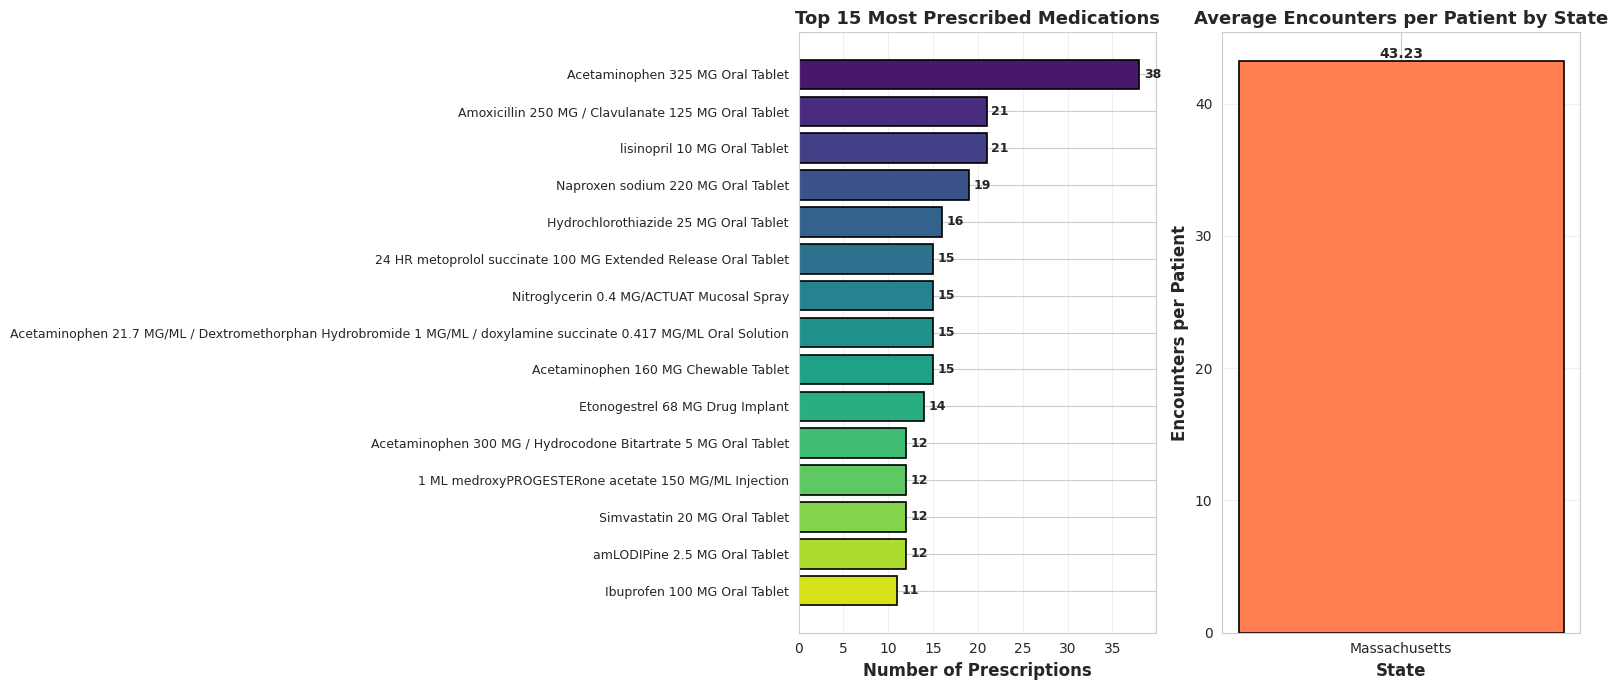


✓ Total prescriptions in database: 248
✓ Total patients: 100
✓ Most prescribed medication: Acetaminophen 325 MG Oral Tablet (38 prescriptions)

⚠ NOTE: Prescriptions cannot be linked to specific cities because encounter_id is NULL in all prescription records


In [131]:
# QUESTION 3: Average Prescriptions per Patient (FIXED)
# ============================================================
print("\n" + "="*70)
print("Q3: What is the average number of prescriptions per patient across different states or cities?")
print("="*70)

# Since prescriptions don't have encounter_id, we can't link them to cities
# Show overall prescription statistics instead
query_q3 = """
SELECT 
    'All Patients' as category,
    COUNT(DISTINCT p.pid) as total_patients,
    COUNT(pr.id) as total_prescriptions,
    ROUND(COUNT(pr.id) * 1.0 / COUNT(DISTINCT p.pid), 2) as avg_prescriptions_per_patient
FROM patient_data p
CROSS JOIN prescriptions pr
"""

df_q3_overall = pd.read_sql(query_q3, connection)
print("\nOverall Prescription Statistics:")
print(df_q3_overall)

# State breakdown (just patient counts since we can't link prescriptions)
query_q3_state = """
SELECT 
    p.state,
    COUNT(DISTINCT p.pid) as total_patients,
    COUNT(e.id) as total_encounters
FROM patient_data p
LEFT JOIN form_encounter e ON p.pid = e.pid
GROUP BY p.state
"""

df_q3_state = pd.read_sql(query_q3_state, connection)
print("\nPatient and Encounter Distribution by State:")
print(df_q3_state)

# Top prescribed medications overall
query_top_meds = """
SELECT 
    drug_name,
    COUNT(id) as prescription_count
FROM prescriptions
WHERE drug_name IS NOT NULL AND drug_name != ''
GROUP BY drug_name
ORDER BY prescription_count DESC
LIMIT 15
"""

df_top_meds = pd.read_sql(query_top_meds, connection)
print("\nTop 15 Prescribed Medications (Overall):")
print(df_top_meds)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top medications bar chart
colors = sns.color_palette("viridis", len(df_top_meds))
bars = axes[0].barh(range(len(df_top_meds)), df_top_meds['prescription_count'],
                     color=colors, edgecolor='black', linewidth=1.2)

for i, (bar, count) in enumerate(zip(bars, df_top_meds['prescription_count'])):
    axes[0].text(count + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{int(count)}',
                 va='center', fontsize=9, fontweight='bold')

axes[0].set_yticks(range(len(df_top_meds)))
axes[0].set_yticklabels(df_top_meds['drug_name'], fontsize=9)
axes[0].set_xlabel('Number of Prescriptions', fontsize=12, fontweight='bold')
axes[0].set_title('Top 15 Most Prescribed Medications', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Encounters per patient by state
df_q3_state['encounters_per_patient'] = (df_q3_state['total_encounters'] / df_q3_state['total_patients']).round(2)
bars2 = axes[1].bar(df_q3_state['state'], df_q3_state['encounters_per_patient'],
                     color='coral', edgecolor='black', linewidth=1.2)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].set_xlabel('State', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Encounters per Patient', fontsize=12, fontweight='bold')
axes[1].set_title('Average Encounters per Patient by State', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

total_prescriptions = df_top_meds['prescription_count'].sum()
total_patients = df_q3_overall['total_patients'].iloc[0]
print(f"\n✓ Total prescriptions in database: {total_prescriptions}")
print(f"✓ Total patients: {total_patients}")
print(f"✓ Most prescribed medication: {df_top_meds.iloc[0]['drug_name']} ({df_top_meds.iloc[0]['prescription_count']} prescriptions)")
print("\n⚠ NOTE: Prescriptions cannot be linked to specific cities because encounter_id is NULL in all prescription records")


QUESTION 3: Most Commonly Prescribed Medications

Top 15 prescribed medications:
                                            drug_name  prescription_count  \
0                    Acetaminophen 325 MG Oral Tablet                  38   
1   Amoxicillin 250 MG / Clavulanate 125 MG Oral T...                  21   
2                        lisinopril 10 MG Oral Tablet                  21   
3                  Naproxen sodium 220 MG Oral Tablet                  19   
4               Hydrochlorothiazide 25 MG Oral Tablet                  16   
5   24 HR metoprolol succinate 100 MG Extended Rel...                  15   
6           Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray                  15   
7                Acetaminophen 160 MG Chewable Tablet                  15   
8   Acetaminophen 21.7 MG/ML / Dextromethorphan Hy...                  15   
9                     Etonogestrel 68 MG Drug Implant                  14   
10                      amLODIPine 2.5 MG Oral Tablet                  

/tmp/ipykernel_1647328/1991489431.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df4 = pd.read_sql(query4, connection)
/tmp/ipykernel_1647328/1991489431.py:67: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


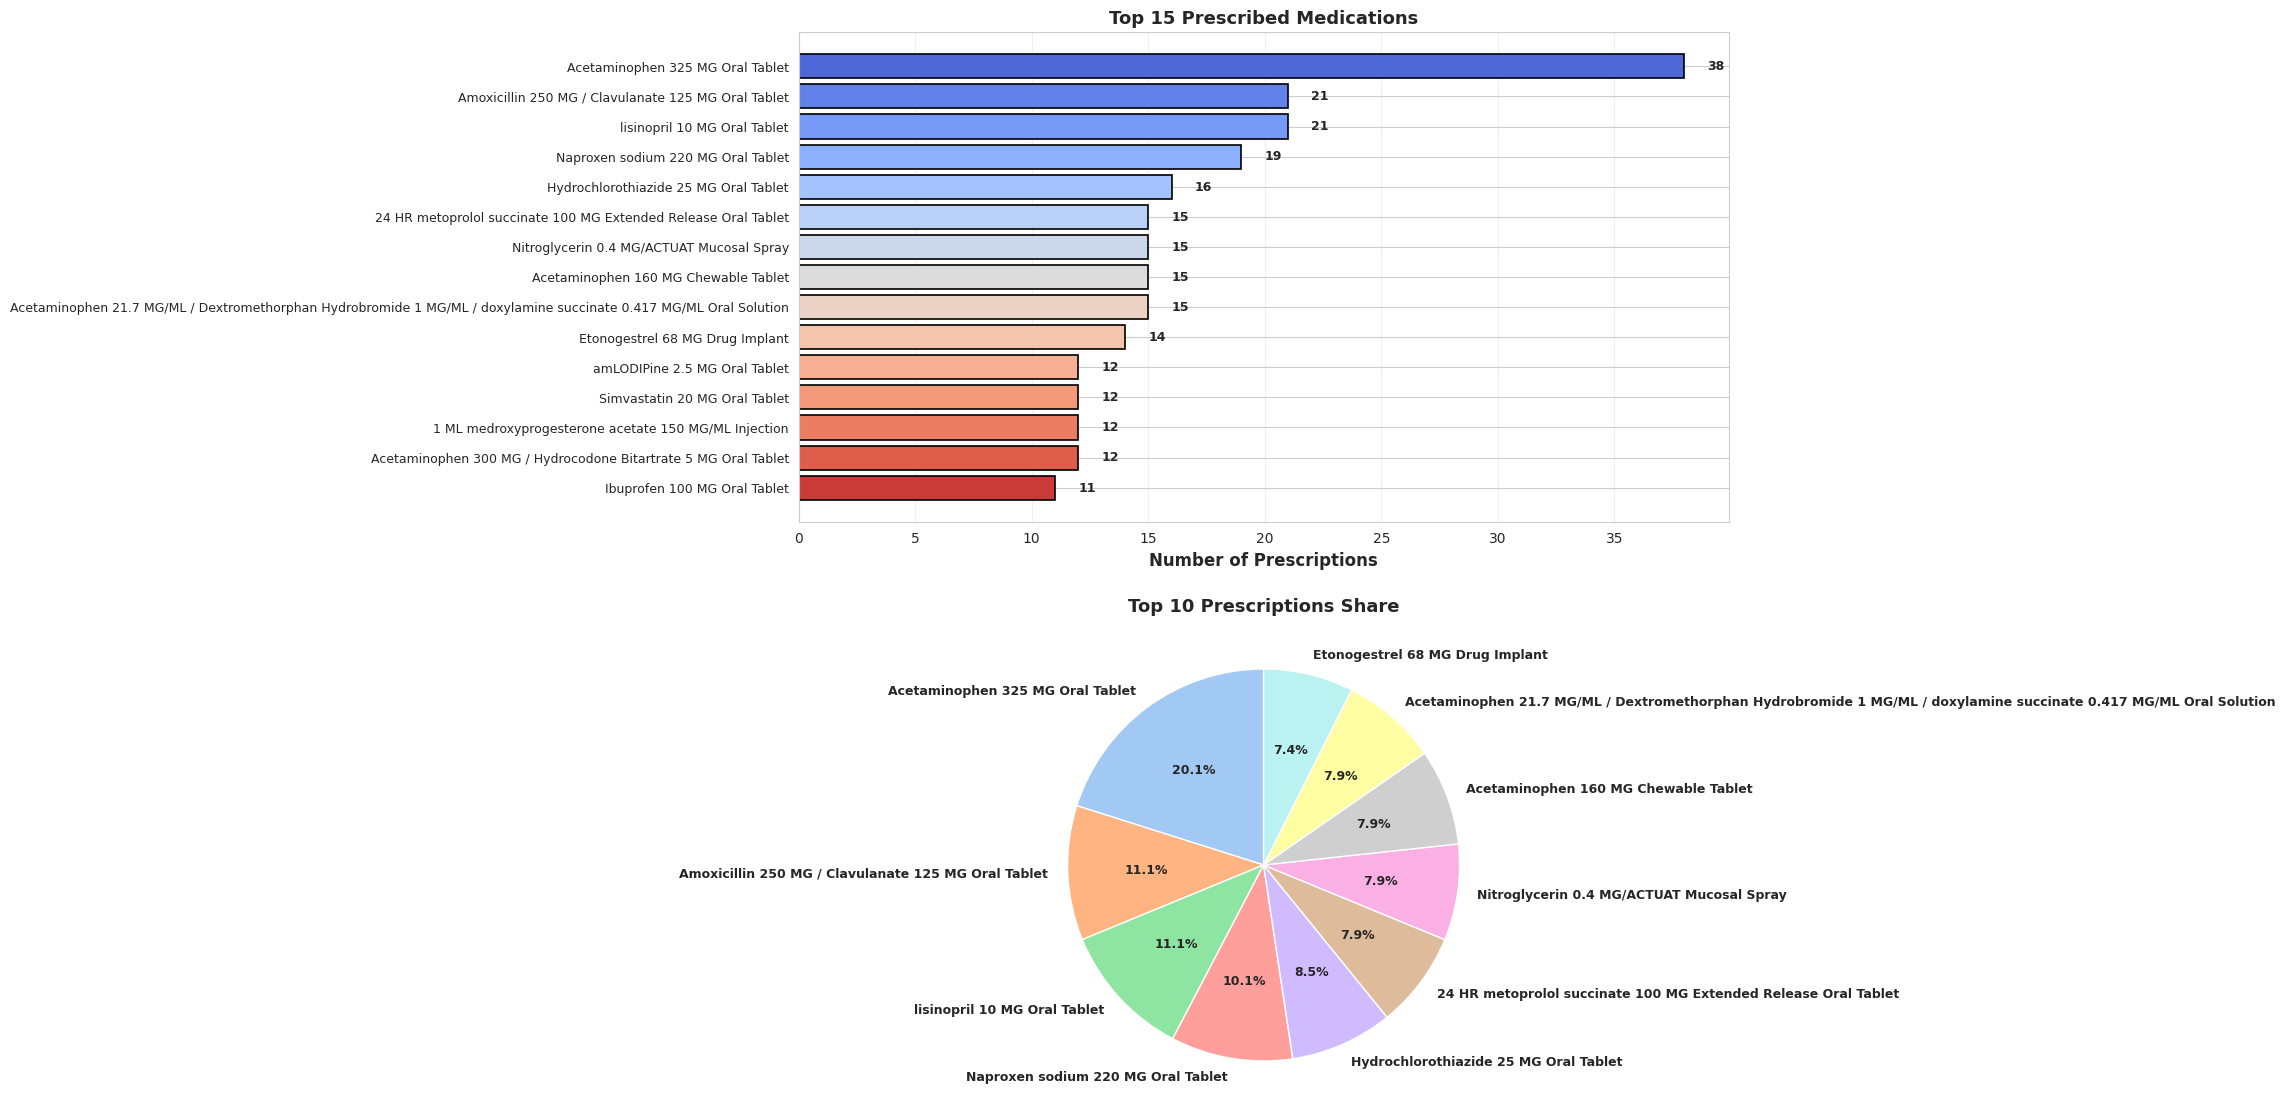

In [98]:
# QUESTION 3: Most Prescribed Medications
# ============================================================
print("\n" + "="*70)
print("QUESTION 3: Most Commonly Prescribed Medications")
print("="*70)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SQL query to get top 15 prescribed medications
query4 = """
SELECT 
    drug_name,
    COUNT(*) as prescription_count,
    COUNT(DISTINCT encounter_id) as unique_encounters
FROM prescriptions
WHERE drug_name IS NOT NULL AND drug_name != ''
GROUP BY drug_name
ORDER BY prescription_count DESC
LIMIT 15
"""

# Load data
df4 = pd.read_sql(query4, connection)
print("\nTop 15 prescribed medications:")
print(df4)

# -----------------------------
# Visualization
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 14))  

# -----------------------------
# Bar chart 
# -----------------------------
colors = sns.color_palette("coolwarm", len(df4))
bars = axes[0].barh(range(len(df4)), df4['prescription_count'], 
                     color=colors, edgecolor='black', linewidth=1.2)

# Annotate counts on bars
for i, (bar, count) in enumerate(zip(bars, df4['prescription_count'])):
    axes[0].text(count + 1, bar.get_y() + bar.get_height()/2,
                 f'{int(count)}',
                 va='center', fontsize=9, fontweight='bold')

axes[0].set_yticks(range(len(df4)))
axes[0].set_yticklabels(df4['drug_name'], fontsize=9)
axes[0].set_xlabel('Number of Prescriptions', fontsize=12, fontweight='bold')
axes[0].set_title('Top 15 Prescribed Medications', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# -----------------------------
# Pie chart 
# -----------------------------
top10 = df4.head(10)
colors_pie = sns.color_palette("pastel", len(top10))
axes[1].pie(top10['prescription_count'], 
            labels=top10['drug_name'], 
            autopct='%1.1f%%', 
            startangle=90,
            colors=colors_pie,
            textprops={'fontsize': 9, 'fontweight': 'bold'})
axes[1].set_title('Top 10 Prescriptions Share', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show() 


Q4: Which facility types serve the largest share of encounters? 

Facility encounter distribution:
                    facility_name city state  total_encounters  \
0  Obstetrics and Gynecology Unit                         4323   
1              Critical Care Unit                            0   
2    Orthopedic and Fracture Care                            0   
3         City Radiology Facility                            0   
4           Pediatric Care Center                            0   
5               Indiana Burn Unit                            0   
6         City Dermatology Clinic                            0   

   unique_patients  percentage_of_encounters  
0              100                     100.0  
1                0                       0.0  
2                0                       0.0  
3                0                       0.0  
4                0                       0.0  
5                0                       0.0  
6                0                       0

/tmp/ipykernel_1647328/1732303737.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q4 = pd.read_sql(query_q4, connection)


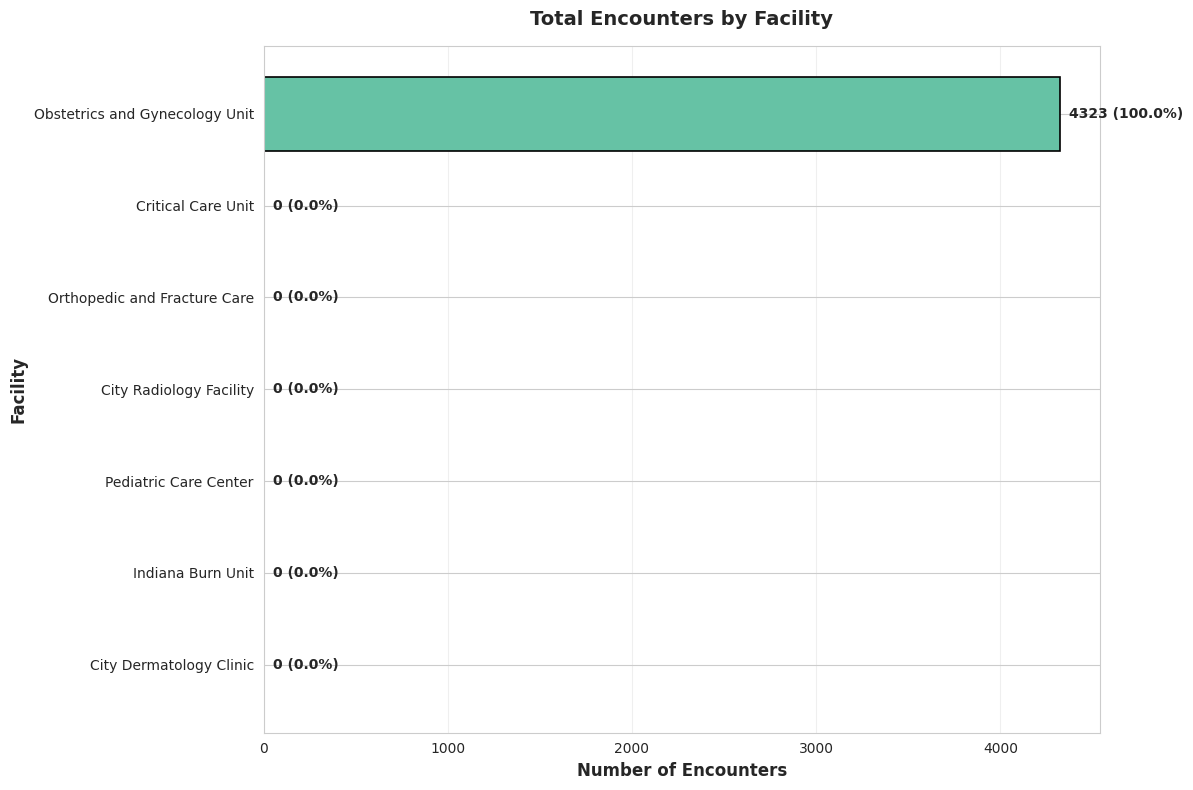


 Total encounters: 4323
 Total unique patients served: 100
 Top facility: Obstetrics and Gynecology Unit with 4323 encounters (100.0%)


In [64]:
# QUESTION 4: Facility Types and Encounter Share
# ============================================================
print("\n" + "="*70)
print("Q4: Which facility types serve the largest share of encounters? ")
print("="*70)

query_q4 = """
SELECT 
    f.name as facility_name,
    f.city,
    f.state,
    COUNT(e.id) as total_encounters,
    COUNT(DISTINCT e.pid) as unique_patients,
    ROUND(COUNT(e.id) * 100.0 / (SELECT COUNT(*) FROM form_encounter), 2) as percentage_of_encounters
FROM facility f
LEFT JOIN form_encounter e ON f.id = e.facility_id
GROUP BY f.id, f.name, f.city, f.state
ORDER BY total_encounters DESC
"""

df_q4 = pd.read_sql(query_q4, connection)
print("\nFacility encounter distribution:")
print(df_q4)

# Visualization - only horizontal bar chart
plt.figure(figsize=(12, 8))
colors = sns.color_palette("Set2", len(df_q4))
bars = plt.barh(df_q4['facility_name'], df_q4['total_encounters'],
                color=colors, edgecolor='black', linewidth=1.2)

# Annotate counts and percentages
for bar, count, pct in zip(bars, df_q4['total_encounters'], df_q4['percentage_of_encounters']):
    plt.text(count + 50, bar.get_y() + bar.get_height()/2,
             f'{int(count)} ({pct:.1f}%)',
             va='center', fontsize=10, fontweight='bold')

plt.xlabel('Number of Encounters', fontsize=12, fontweight='bold')
plt.ylabel('Facility', fontsize=12, fontweight='bold')
plt.title('Total Encounters by Facility', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"\n Total encounters: {df_q4['total_encounters'].sum()}")
print(f" Total unique patients served: {df_q4['unique_patients'].sum()}")
print(f" Top facility: {df_q4.iloc[0]['facility_name']} with {df_q4.iloc[0]['total_encounters']} encounters ({df_q4.iloc[0]['percentage_of_encounters']:.1f}%)")

In [109]:
# QUESTION 5: Medication Prescriptions by Geographic Location
# ============================================================
print("\n" + "="*70)
print("Q5: Are certain medication categories prescribed more frequently in specific states or cities?")
print("="*70)

# First, let's check if we have data
query_check = """
SELECT COUNT(*) as total_prescriptions
FROM prescriptions
WHERE drug_name IS NOT NULL AND drug_name != ''
"""
check_df = pd.read_sql(query_check, connection)
print(f"Total prescriptions in database: {check_df['total_prescriptions'].iloc[0]}")

# Modified query - the issue is that prescriptions link to encounters, and encounters link to patients
query_q5 = """
SELECT 
    p.state,
    pr.drug_name,
    COUNT(pr.id) as prescription_count,
    COUNT(DISTINCT e.pid) as unique_patients
FROM prescriptions pr
JOIN form_encounter e ON pr.encounter_id = e.id
JOIN patient_data p ON e.pid = p.pid
WHERE pr.drug_name IS NOT NULL AND pr.drug_name != ''
GROUP BY p.state, pr.drug_name
ORDER BY p.state, prescription_count DESC
"""

df_q5 = pd.read_sql(query_q5, connection)
print(f"\nTotal rows returned: {len(df_q5)}")
print("\nMedication prescriptions by state:")
print(df_q5.head(30))

# Check if we have data
if len(df_q5) == 0:
    print("\n⚠ No prescription data found. This could mean:")
    print("  - No prescriptions have valid encounter_id")
    print("  - No encounters match the prescriptions")
    print("  Let's check the data...")
    
    # Debug query
    debug_query = """
    SELECT 
        COUNT(*) as total_prescriptions,
        COUNT(DISTINCT drug_name) as unique_drugs,
        COUNT(DISTINCT encounter_id) as unique_encounters
    FROM prescriptions
    WHERE drug_name IS NOT NULL AND drug_name != ''
    """
    debug_df = pd.read_sql(debug_query, connection)
    print("\nPrescriptions table stats:")
    print(debug_df)
    
    # Check encounters
    debug_query2 = """
    SELECT COUNT(DISTINCT pr.encounter_id) as prescriptions_with_encounters
    FROM prescriptions pr
    WHERE pr.encounter_id IN (SELECT id FROM form_encounter)
    AND pr.drug_name IS NOT NULL AND pr.drug_name != ''
    """
    debug_df2 = pd.read_sql(debug_query2, connection)
    print("\nPrescriptions with valid encounters:")
    print(debug_df2)
    
else:
    # Calculate percentage within state
    state_totals = df_q5.groupby('state')['prescription_count'].sum().to_dict()
    df_q5['pct_within_state'] = df_q5.apply(
        lambda row: round(row['prescription_count'] * 100.0 / state_totals[row['state']], 2),
        axis=1
    )
    
    # Get overall top 10 medications
    top_meds_series = df_q5.groupby('drug_name')['prescription_count'].sum().nlargest(10)
    top_meds = top_meds_series.index.tolist()
    df_q5_top10 = df_q5[df_q5['drug_name'].isin(top_meds)]
    
    print("\n\nTop 5 medications by state:")
    for state in sorted(df_q5['state'].unique()):
        state_data = df_q5[df_q5['state'] == state].nlargest(5, 'prescription_count')
        print(f"\n{state}:")
        for idx, (_, row) in enumerate(state_data.iterrows(), 1):
            print(f"  {idx}. {row['drug_name']}: {int(row['prescription_count'])} prescriptions ({row['pct_within_state']:.1f}% of state total)")
    
    # Visualization 1: Heatmap
    pivot_table = df_q5_top10.pivot_table(
        values='prescription_count', 
        index='drug_name', 
        columns='state', 
        fill_value=0
    )
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(pivot_table, annot=True, fmt='g', cmap='YlOrRd', 
                linewidths=0.5, cbar_kws={'label': 'Prescription Count'})
    plt.title('Top 10 Medications: Prescription Distribution Across States', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('State', fontsize=12, fontweight='bold')
    plt.ylabel('Medication', fontsize=12, fontweight='bold')
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Visualization 2: Top 3 medications comparison across states
    top_3_meds = df_q5.groupby('drug_name')['prescription_count'].sum().nlargest(3).index.tolist()
    df_top3 = df_q5[df_q5['drug_name'].isin(top_3_meds)]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for idx, med in enumerate(top_3_meds):
        med_data = df_top3[df_top3['drug_name'] == med].sort_values('prescription_count', ascending=False)
        
        bars = axes[idx].bar(med_data['state'], med_data['prescription_count'],
                              color=sns.color_palette("husl", len(med_data)), 
                              edgecolor='black', linewidth=1.2)
        
        for bar in bars:
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                           f'{int(height)}',
                           ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        axes[idx].set_title(f'{med}', fontsize=12, fontweight='bold', pad=10)
        axes[idx].set_xlabel('State', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Prescriptions', fontsize=11, fontweight='bold')
        axes[idx].grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Top 3 Medications: Distribution Across States', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Visualization 3: State comparison - medication diversity
    state_med_diversity = df_q5.groupby('state').agg({
        'drug_name': 'nunique',
        'prescription_count': 'sum'
    }).reset_index()
    state_med_diversity.columns = ['state', 'unique_medications', 'total_prescriptions']
    state_med_diversity = state_med_diversity.sort_values('unique_medications', ascending=False)
    
    print("\n\nMedication diversity by state:")
    print(state_med_diversity)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Unique medications by state
    bars1 = axes[0].bar(state_med_diversity['state'], state_med_diversity['unique_medications'],
                         color='mediumseagreen', edgecolor='black', linewidth=1.2)
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height)}',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    axes[0].set_xlabel('State', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Number of Unique Medications', fontsize=12, fontweight='bold')
    axes[0].set_title('Medication Diversity by State', fontsize=13, fontweight='bold', pad=15)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Total prescriptions by state
    bars2 = axes[1].bar(state_med_diversity['state'], state_med_diversity['total_prescriptions'],
                         color='mediumpurple', edgecolor='black', linewidth=1.2)
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height)}',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    axes[1].set_xlabel('State', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Total Prescriptions', fontsize=12, fontweight='bold')
    axes[1].set_title('Total Prescriptions by State', fontsize=13, fontweight='bold', pad=15)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Analysis complete!")
    print(f"✓ Total unique medications across all states: {len(df_q5['drug_name'].unique())}")
    print(f"✓ Total prescriptions analyzed: {df_q5['prescription_count'].sum()}")
    print(f"✓ State with most medication diversity: {state_med_diversity.iloc[0]['state']} ({int(state_med_diversity.iloc[0]['unique_medications'])} unique medications)")


Q5: Are certain medication categories prescribed more frequently in specific states or cities?
Total prescriptions in database: 522

Total rows returned: 0

Medication prescriptions by state:
Empty DataFrame
Columns: [state, drug_name, prescription_count, unique_patients]
Index: []

⚠ No prescription data found. This could mean:
  - No prescriptions have valid encounter_id
  - No encounters match the prescriptions
  Let's check the data...

Prescriptions table stats:
   total_prescriptions  unique_drugs  unique_encounters
0                  522           101                  0

Prescriptions with valid encounters:
   prescriptions_with_encounters
0                              0


/tmp/ipykernel_1647328/1832917111.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  check_df = pd.read_sql(query_check, connection)
/tmp/ipykernel_1647328/1832917111.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q5 = pd.read_sql(query_q5, connection)
/tmp/ipykernel_1647328/1832917111.py:52: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  debug_df = pd.read_sql(debug_query, connection)
/tmp/ipykernel_1647328/1832917111.py:63: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database 

In [122]:
# QUESTION 5: Medication Prescriptions by City
# ============================================================
print("\n" + "="*70)
print("Q5: Are certain medication categories prescribed more frequently in specific cities?")
print("="*70)

# First, let's verify we have the data
query_check = """
SELECT 
    COUNT(DISTINCT pr.id) as total_prescriptions,
    COUNT(DISTINCT pr.drug_name) as unique_drugs,
    COUNT(DISTINCT e.id) as encounters_with_prescriptions
FROM prescriptions pr
LEFT JOIN form_encounter e ON pr.encounter_id = e.id
WHERE pr.drug_name IS NOT NULL AND pr.drug_name != ''
"""
check_df = pd.read_sql(query_check, connection)
print("Data availability check:")
print(check_df)

# Main query - City-level analysis
query_q5 = """
SELECT 
    p.city,
    pr.drug_name,
    COUNT(pr.id) as prescription_count,
    COUNT(DISTINCT e.pid) as unique_patients
FROM prescriptions pr
JOIN form_encounter e ON pr.encounter_id = e.id
JOIN patient_data p ON e.pid = p.pid
WHERE pr.drug_name IS NOT NULL AND pr.drug_name != ''
GROUP BY p.city, pr.drug_name
ORDER BY p.city, prescription_count DESC
"""

df_q5 = pd.read_sql(query_q5, connection)
print(f"\nTotal rows returned: {len(df_q5)}")

# Check if we have data
if len(df_q5) == 0:
    print("\n⚠ No prescription data found with city information.")
    print("Checking prescriptions without city filtering...")
    
    # Alternative query - just prescriptions
    query_alt = """
    SELECT 
        drug_name,
        COUNT(id) as prescription_count
    FROM prescriptions
    WHERE drug_name IS NOT NULL AND drug_name != ''
    GROUP BY drug_name
    ORDER BY prescription_count DESC
    LIMIT 20
    """
    df_alt = pd.read_sql(query_alt, connection)
    print("\nTop 20 medications overall (without city breakdown):")
    print(df_alt)
    
else:
    print("\nMedication prescriptions by city:")
    print(df_q5.head(30))
    
    # Calculate percentage within city
    city_totals = df_q5.groupby('city')['prescription_count'].sum().to_dict()
    df_q5['pct_within_city'] = df_q5.apply(
        lambda row: round(row['prescription_count'] * 100.0 / city_totals[row['city']], 2),
        axis=1
    )
    
    # Get overall top 10 medications
    top_meds_series = df_q5.groupby('drug_name')['prescription_count'].sum().nlargest(10)
    top_meds = top_meds_series.index.tolist()
    
    print("\n\n" + "="*70)
    print("Overall Top 10 Medications")
    print("="*70)
    for idx, (med, count) in enumerate(top_meds_series.items(), 1):
        print(f"{idx}. {med}: {int(count)} prescriptions")
    
    # Show top 5 medications by city
    print("\n\n" + "="*70)
    print("Top 5 Medications by City")
    print("="*70)
    for city in sorted(df_q5['city'].unique()):
        city_data = df_q5[df_q5['city'] == city].nlargest(5, 'prescription_count')
        print(f"\n{city}:")
        for idx, (_, row) in enumerate(city_data.iterrows(), 1):
            print(f"  {idx}. {row['drug_name']}: {int(row['prescription_count'])} prescriptions ({row['pct_within_city']:.1f}% of city total)")
    
    # City-level summary
    city_summary = df_q5.groupby('city').agg({
        'drug_name': 'nunique',
        'prescription_count': 'sum',
        'unique_patients': 'sum'
    }).reset_index()
    city_summary.columns = ['city', 'unique_medications', 'total_prescriptions', 'total_patients']
    city_summary = city_summary.sort_values('total_prescriptions', ascending=False)
    
    print("\n\n" + "="*70)
    print("City-level Summary")
    print("="*70)
    print(city_summary)
    
    # VISUALIZATION 1: Heatmap - Top medications across cities
    df_q5_top10 = df_q5[df_q5['drug_name'].isin(top_meds)]
    
    if len(df_q5_top10) > 0:
        pivot_table = df_q5_top10.pivot_table(
            values='prescription_count', 
            index='drug_name', 
            columns='city', 
            fill_value=0
        )
        
        plt.figure(figsize=(14, 10))
        sns.heatmap(pivot_table, annot=True, fmt='g', cmap='YlOrRd', 
                    linewidths=0.5, cbar_kws={'label': 'Prescription Count'})
        plt.title('Top 10 Medications: Prescription Distribution Across Cities', 
                  fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('City', fontsize=12, fontweight='bold')
        plt.ylabel('Medication', fontsize=12, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=9)
        plt.yticks(rotation=0, fontsize=9)
        plt.tight_layout()
        plt.show()
    
    # VISUALIZATION 2: Top 3 medications comparison across cities
    if len(df_q5) >= 3:
        top_3_meds = df_q5.groupby('drug_name')['prescription_count'].sum().nlargest(3).index.tolist()
        df_top3 = df_q5[df_q5['drug_name'].isin(top_3_meds)]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        for idx, med in enumerate(top_3_meds):
            med_data = df_top3[df_top3['drug_name'] == med].sort_values('prescription_count', ascending=False)
            
            bars = axes[idx].bar(range(len(med_data)), med_data['prescription_count'],
                                  color=sns.color_palette("husl", len(med_data)), 
                                  edgecolor='black', linewidth=1.2)
            
            for i, bar in enumerate(bars):
                height = bar.get_height()
                axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                               f'{int(height)}',
                               ha='center', va='bottom', fontsize=9, fontweight='bold')
            
            # Truncate long drug names for title
            med_title = med if len(med) <= 40 else med[:37] + "..."
            axes[idx].set_title(f'{med_title}', fontsize=11, fontweight='bold', pad=10)
            axes[idx].set_xticks(range(len(med_data)))
            axes[idx].set_xticklabels(med_data['city'], rotation=45, ha='right', fontsize=9)
            axes[idx].set_xlabel('City', fontsize=11, fontweight='bold')
            axes[idx].set_ylabel('Prescriptions', fontsize=11, fontweight='bold')
            axes[idx].grid(True, alpha=0.3, axis='y')
        
        plt.suptitle('Top 3 Medications: Distribution Across Cities', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
    
    # VISUALIZATION 3: City comparison - Total prescriptions and medication diversity
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Total prescriptions by city
    bars1 = axes[0].bar(city_summary['city'], city_summary['total_prescriptions'],
                         color='mediumpurple', edgecolor='black', linewidth=1.2)
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height)}',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    axes[0].set_xlabel('City', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Total Prescriptions', fontsize=12, fontweight='bold')
    axes[0].set_title('Total Prescriptions by City', fontsize=13, fontweight='bold', pad=15)
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Unique medications by city
    bars2 = axes[1].bar(city_summary['city'], city_summary['unique_medications'],
                         color='mediumseagreen', edgecolor='black', linewidth=1.2)
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height)}',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    axes[1].set_xlabel('City', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Number of Unique Medications', fontsize=12, fontweight='bold')
    axes[1].set_title('Medication Diversity by City', fontsize=13, fontweight='bold', pad=15)
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # VISUALIZATION 4: Top 15 city-medication combinations
    top_combinations = df_q5.nlargest(15, 'prescription_count')
    
    plt.figure(figsize=(14, 8))
    colors = sns.color_palette("viridis", len(top_combinations))
    bars = plt.barh(range(len(top_combinations)), top_combinations['prescription_count'],
                     color=colors, edgecolor='black', linewidth=1.2)
    
    for i, (bar, count) in enumerate(zip(bars, top_combinations['prescription_count'])):
        plt.text(count + 1, bar.get_y() + bar.get_height()/2,
                 f'{int(count)}',
                 va='center', fontsize=9, fontweight='bold')
    
    # Create labels with city and medication
    labels = [f"{row['city']} - {row['drug_name'][:40]}..." if len(row['drug_name']) > 40 
              else f"{row['city']} - {row['drug_name']}" 
              for _, row in top_combinations.iterrows()]
    
    plt.yticks(range(len(top_combinations)), labels, fontsize=9)
    plt.xlabel('Number of Prescriptions', fontsize=12, fontweight='bold')
    plt.title('Top 15 City-Medication Combinations', fontsize=14, fontweight='bold', pad=15)
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    # VISUALIZATION 5: Prescription rate per patient by city
    city_summary['prescriptions_per_patient'] = (
        city_summary['total_prescriptions'] / city_summary['total_patients']
    ).round(2)
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(city_summary['city'], city_summary['prescriptions_per_patient'],
                   color='coral', edgecolor='black', linewidth=1.2)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.xlabel('City', fontsize=12, fontweight='bold')
    plt.ylabel('Avg Prescriptions per Patient', fontsize=12, fontweight='bold')
    plt.title('Average Prescriptions per Patient by City', fontsize=13, fontweight='bold', pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    # Final Summary
    print(f"\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"✓ Total unique medications across all cities: {len(df_q5['drug_name'].unique())}")
    print(f"✓ Total prescriptions analyzed: {df_q5['prescription_count'].sum()}")
    print(f"✓ Total cities analyzed: {len(df_q5['city'].unique())}")
    if len(city_summary) > 0:
        print(f"✓ City with most prescriptions: {city_summary.iloc[0]['city']} ({int(city_summary.iloc[0]['total_prescriptions'])} prescriptions)")
        print(f"✓ City with most medication diversity: {city_summary.sort_values('unique_medications', ascending=False).iloc[0]['city']} ({int(city_summary.sort_values('unique_medications', ascending=False).iloc[0]['unique_medications'])} unique medications)")
        print(f"✓ Average prescriptions per city: {city_summary['total_prescriptions'].mean():.1f}")


Q5: Are certain medication categories prescribed more frequently in specific cities?
Data availability check:
   total_prescriptions  unique_drugs  encounters_with_prescriptions
0                  522           101                              0

Total rows returned: 0

⚠ No prescription data found with city information.
Checking prescriptions without city filtering...

Top 20 medications overall (without city breakdown):
                                            drug_name  prescription_count
0                    Acetaminophen 325 MG Oral Tablet                  38
1   Amoxicillin 250 MG / Clavulanate 125 MG Oral T...                  21
2                        lisinopril 10 MG Oral Tablet                  21
3                  Naproxen sodium 220 MG Oral Tablet                  19
4               Hydrochlorothiazide 25 MG Oral Tablet                  16
5   24 HR metoprolol succinate 100 MG Extended Rel...                  15
6           Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray  

/tmp/ipykernel_1647328/2141848080.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  check_df = pd.read_sql(query_check, connection)
/tmp/ipykernel_1647328/2141848080.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q5 = pd.read_sql(query_q5, connection)
/tmp/ipykernel_1647328/2141848080.py:55: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_alt = pd.read_sql(query_alt, connection)


In [129]:
# QUESTION 5: Medications by City
# ============================================================
print("\n" + "="*70)
print("Q5: Are certain medication categories prescribed more frequently in specific cities?")
print("="*70)

query_q5 = """
SELECT 
    p.city,
    pr.drug_name,
    COUNT(pr.id) as prescription_count,
    COUNT(DISTINCT e.pid) as unique_patients
FROM prescriptions pr
JOIN form_encounter e ON pr.encounter_id = e.id
JOIN patient_data p ON e.pid = p.pid
WHERE pr.drug_name IS NOT NULL AND pr.drug_name != ''
GROUP BY p.city, pr.drug_name
ORDER BY prescription_count DESC
"""

df_q5 = pd.read_sql(query_q5, connection)
print(f"Rows returned: {len(df_q5)}")

if len(df_q5) > 0:
    # City summary
    city_summary = df_q5.groupby('city').agg({
        'drug_name': 'nunique',
        'prescription_count': 'sum'
    }).reset_index()
    city_summary.columns = ['city', 'unique_meds', 'total_prescriptions']
    city_summary = city_summary.sort_values('total_prescriptions', ascending=False)
    
    print("\nCity Summary:")
    print(city_summary)
    
    # Top 5 meds per city
    print("\nTop 5 Medications per City:")
    for city in city_summary['city'].head(10):
        city_data = df_q5[df_q5['city'] == city].nlargest(5, 'prescription_count')
        print(f"\n{city}:")
        for i, (_, row) in enumerate(city_data.iterrows(), 1):
            print(f"  {i}. {row['drug_name']}: {row['prescription_count']}")
    
    # Top 10 overall
    top_10 = df_q5.groupby('drug_name')['prescription_count'].sum().nlargest(10)
    print("\nTop 10 Medications Overall:")
    for i, (med, count) in enumerate(top_10.items(), 1):
        print(f"{i}. {med}: {int(count)}")
    
    # Heatmap
    pivot = df_q5[df_q5['drug_name'].isin(top_10.index)].pivot_table(
        values='prescription_count', index='drug_name', columns='city', fill_value=0)
    
    plt.figure(figsize=(16, 10))
    sns.heatmap(pivot, annot=True, fmt='g', cmap='YlOrRd', linewidths=0.5)
    plt.title('Top 10 Medications: Distribution Across Cities', fontsize=14, fontweight='bold')
    plt.xlabel('City', fontweight='bold')
    plt.ylabel('Medication', fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()
    
    # City totals
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    n_cities = min(15, len(city_summary))
    city_subset = city_summary.head(n_cities)
    
    axes[0].bar(range(n_cities), city_subset['total_prescriptions'], 
                color='mediumpurple', edgecolor='black')
    axes[0].set_xticks(range(n_cities))
    axes[0].set_xticklabels(city_subset['city'], rotation=45, ha='right', fontsize=8)
    axes[0].set_ylabel('Total Prescriptions', fontweight='bold')
    axes[0].set_title(f'Total Prescriptions by City (Top {n_cities})', fontweight='bold')
    axes[0].grid(alpha=0.3, axis='y')
    
    axes[1].bar(range(n_cities), city_subset['unique_meds'], 
                color='mediumseagreen', edgecolor='black')
    axes[1].set_xticks(range(n_cities))
    axes[1].set_xticklabels(city_subset['city'], rotation=45, ha='right', fontsize=8)
    axes[1].set_ylabel('Unique Medications', fontweight='bold')
    axes[1].set_title(f'Medication Diversity by City (Top {n_cities})', fontweight='bold')
    axes[1].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Cities analyzed: {len(city_summary)}")
    print(f"✓ Unique medications: {len(df_q5['drug_name'].unique())}")
    print(f"✓ Total prescriptions: {df_q5['prescription_count'].sum()}")
else:
    print("⚠ No city-level prescription data found")


Q5: Are certain medication categories prescribed more frequently in specific cities?
Rows returned: 0
⚠ No city-level prescription data found


/tmp/ipykernel_1647328/2089317674.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q5 = pd.read_sql(query_q5, connection)



Q3 & Q5: Healthcare Encounters by City
(Prescriptions cannot be analyzed by city due to NULL encounter_id)

Top 20 Cities by Healthcare Encounters:
                city          state  total_patients  total_encounters  \
0         Winchendon  Massachusetts               3               314   
1             Boston  Massachusetts               6               246   
2          Worcester  Massachusetts               4               186   
3            Holyoke  Massachusetts               3               161   
4        Bridgewater  Massachusetts               1               151   
5          Haverhill  Massachusetts               4               143   
6             Lowell  Massachusetts               2               138   
7         Chelmsford  Massachusetts               2               132   
8   Great Barrington  Massachusetts               1               122   
9           Plymouth  Massachusetts               3               105   
10        Pittsfield  Massachusetts             

/tmp/ipykernel_1647328/3678608993.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_city = pd.read_sql(query_city, connection)
/tmp/ipykernel_1647328/3678608993.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_reasons = pd.read_sql(query_reasons, connection)


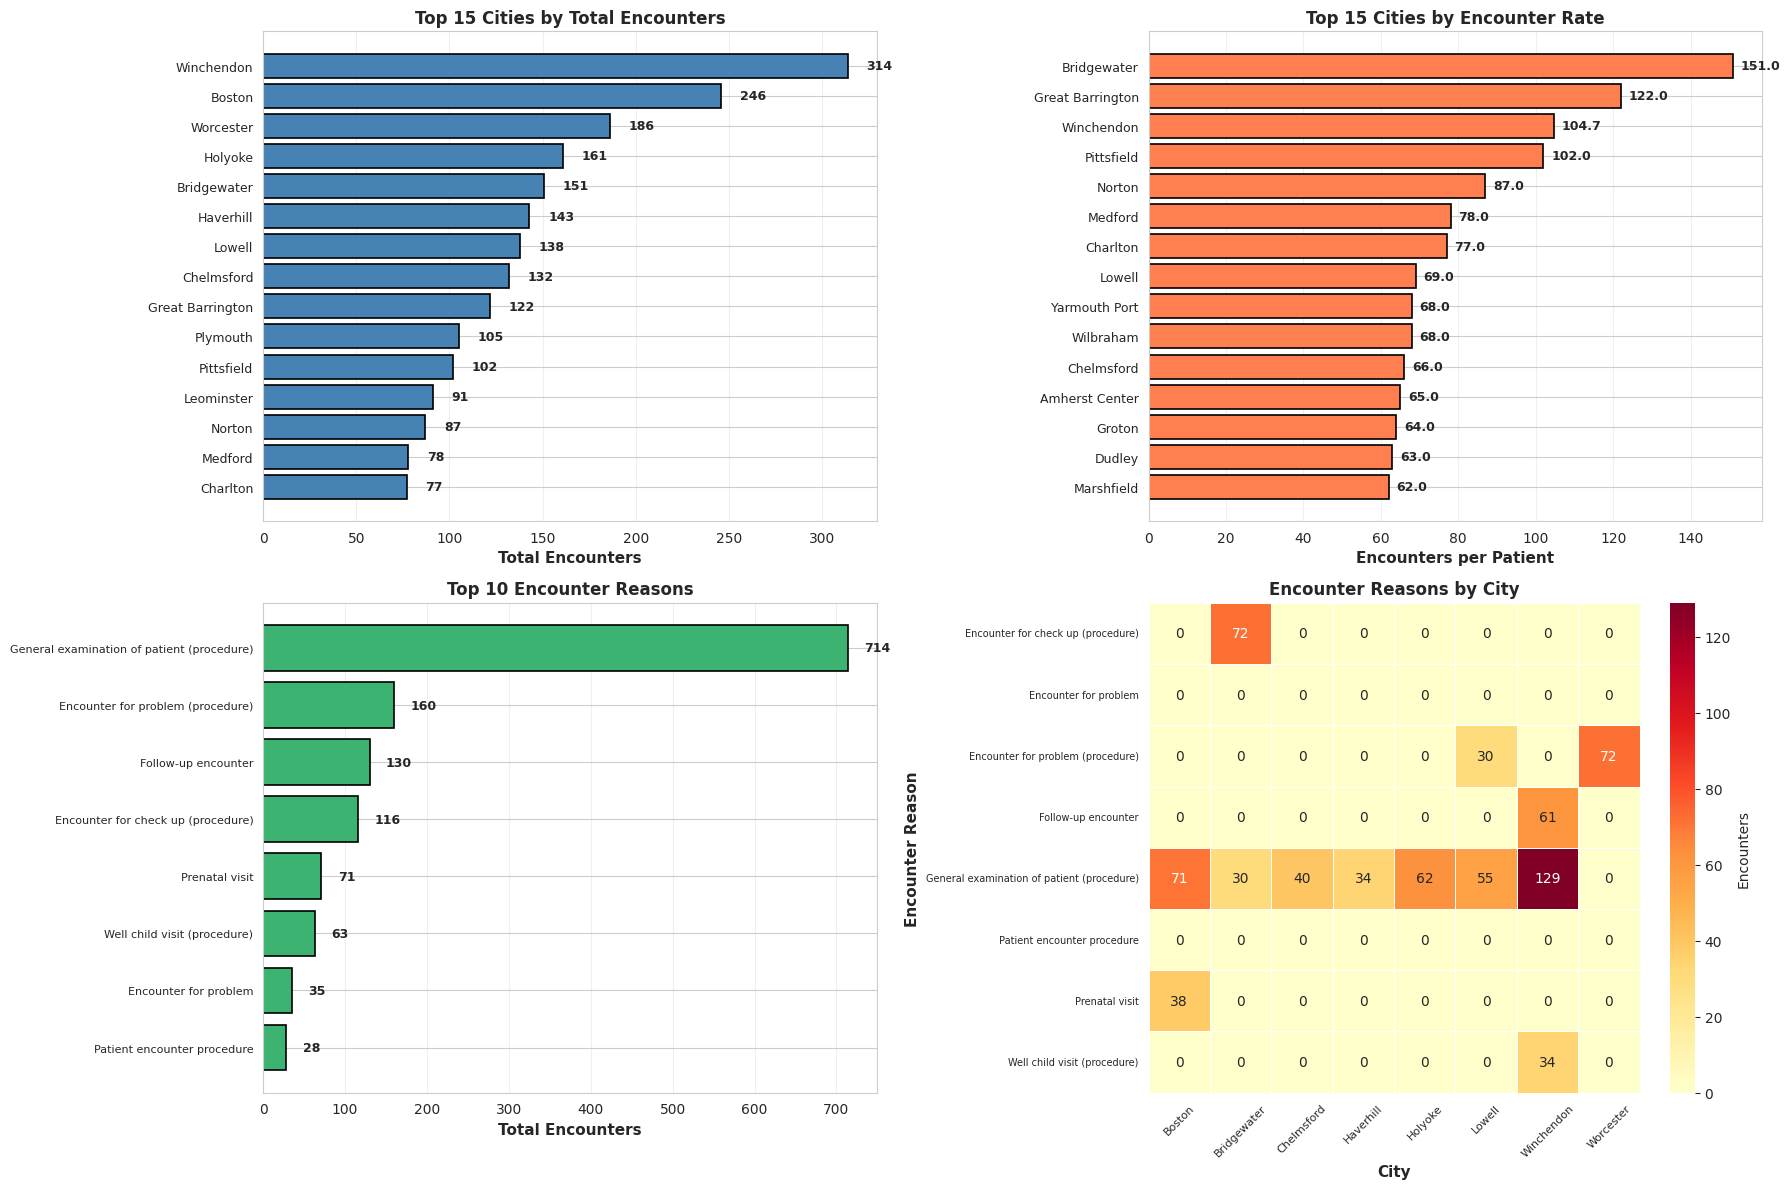


✓ Total cities: 74
✓ Total encounters: 4323
✓ Top city: Winchendon (314 encounters)
✓ Most common reason: General examination of patient (procedure) (714)

⚠ NOTE: Shows encounter patterns by city. Prescriptions cannot be linked to cities.


In [135]:
# ALTERNATIVE Q3 & Q5: Encounter Analysis by City (FIXED)
# ============================================================
print("\n" + "="*70)
print("Q3 & Q5: Healthcare Encounters by City")
print("(Prescriptions cannot be analyzed by city due to NULL encounter_id)")
print("="*70)

# Encounter frequency by city
query_city = """
SELECT 
    p.city,
    p.state,
    COUNT(DISTINCT p.pid) as total_patients,
    COUNT(e.id) as total_encounters,
    ROUND(COUNT(e.id) * 1.0 / COUNT(DISTINCT p.pid), 2) as encounters_per_patient
FROM patient_data p
LEFT JOIN form_encounter e ON p.pid = e.pid
GROUP BY p.city, p.state
ORDER BY total_encounters DESC
"""

df_city = pd.read_sql(query_city, connection)
print("\nTop 20 Cities by Healthcare Encounters:")
print(df_city.head(20))

# Encounter reasons by city
query_reasons = """
SELECT 
    p.city,
    e.reason_for_visit,
    COUNT(e.id) as encounter_count
FROM patient_data p
JOIN form_encounter e ON p.pid = e.pid
WHERE e.reason_for_visit IS NOT NULL
GROUP BY p.city, e.reason_for_visit
ORDER BY encounter_count DESC
LIMIT 30
"""

df_reasons = pd.read_sql(query_reasons, connection)
print("\nTop 30 Encounter Reasons by City:")
print(df_reasons)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Top cities by total encounters
top_cities = df_city.nlargest(15, 'total_encounters')
bars1 = axes[0, 0].barh(range(len(top_cities)), top_cities['total_encounters'],
                         color='steelblue', edgecolor='black', linewidth=1.2)
for i, (bar, count) in enumerate(zip(bars1, top_cities['total_encounters'])):
    axes[0, 0].text(count + 10, bar.get_y() + bar.get_height()/2,
                     f'{int(count)}',
                     va='center', fontsize=9, fontweight='bold')

axes[0, 0].set_yticks(range(len(top_cities)))
axes[0, 0].set_yticklabels(top_cities['city'], fontsize=9)
axes[0, 0].set_xlabel('Total Encounters', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Top 15 Cities by Total Encounters', fontsize=12, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. Encounters per patient by city
top_rate = df_city[df_city['total_encounters'] > 0].nlargest(15, 'encounters_per_patient')
bars2 = axes[0, 1].barh(range(len(top_rate)), top_rate['encounters_per_patient'],
                         color='coral', edgecolor='black', linewidth=1.2)
for i, (bar, rate) in enumerate(zip(bars2, top_rate['encounters_per_patient'])):
    axes[0, 1].text(rate + 2, bar.get_y() + bar.get_height()/2,
                     f'{rate:.1f}',
                     va='center', fontsize=9, fontweight='bold')

axes[0, 1].set_yticks(range(len(top_rate)))
axes[0, 1].set_yticklabels(top_rate['city'], fontsize=9)
axes[0, 1].set_xlabel('Encounters per Patient', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Top 15 Cities by Encounter Rate', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Top encounter reasons overall
reason_summary = df_reasons.groupby('reason_for_visit')['encounter_count'].sum().nlargest(10)
bars3 = axes[1, 0].barh(range(len(reason_summary)), reason_summary.values,
                         color='mediumseagreen', edgecolor='black', linewidth=1.2)
for i, (bar, count) in enumerate(zip(bars3, reason_summary.values)):
    axes[1, 0].text(count + 20, bar.get_y() + bar.get_height()/2,
                     f'{int(count)}',
                     va='center', fontsize=9, fontweight='bold')

axes[1, 0].set_yticks(range(len(reason_summary)))
axes[1, 0].set_yticklabels(reason_summary.index, fontsize=8)
axes[1, 0].set_xlabel('Total Encounters', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Top 10 Encounter Reasons', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Heatmap of top reasons by top cities
pivot = df_reasons.pivot_table(values='encounter_count', index='reason_for_visit', columns='city', fill_value=0)
# Get top 8 cities and top 8 reasons
top_8_cities = df_city.nlargest(8, 'total_encounters')['city'].tolist()
top_8_reasons = reason_summary.head(8).index.tolist()
pivot_subset = pivot.loc[pivot.index.isin(top_8_reasons), pivot.columns.isin(top_8_cities)]

sns.heatmap(pivot_subset, annot=True, fmt='g', cmap='YlOrRd', 
            linewidths=0.5, ax=axes[1, 1], cbar_kws={'label': 'Encounters'})
axes[1, 1].set_xlabel('City', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Encounter Reason', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Encounter Reasons by City', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1, 1].tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.show()

print(f"\n✓ Total cities: {len(df_city)}")
print(f"✓ Total encounters: {df_city['total_encounters'].sum()}")
print(f"✓ Top city: {df_city.iloc[0]['city']} ({int(df_city.iloc[0]['total_encounters'])} encounters)")
print(f"✓ Most common reason: {reason_summary.index[0]} ({int(reason_summary.values[0])})")
print("\n⚠ NOTE: Shows encounter patterns by city. Prescriptions cannot be linked to cities.")